In [1]:
import numpy as np
import duckdb

In [2]:
cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/x_e_work/"

/storage/project/r-js130-0/pagrawala6/x_e_work


In [ ]:
# Global variables to store energy data (loaded once)
energies_m = None
J_vals = None


def load_energy_data():
    """Load energy levels from database once"""
    global energies_m, J_vals
    if energies_m is None:
        conn = duckdb.connect('energylevels2.duckdb')
        df = conn.execute(
            "SELECT * FROM energy_levels WHERE el_state = 'X3Sigma-' and J < 150 and v < 40 ORDER BY energy" 
            ).df()
        conn.close()
        
        energies_cm = list(df.energy)
        J_vals = list(df.J)
        energies_m = [(energy_cm + 794.590195753252-791.716307 ) / 1e-2 for energy_cm in energies_cm]
        print(f"Loaded {len(energies_cm)} energy levels")

def Q(T_Kelvin, batch_size=500, tolerance=1e-5, verbose=False):

    """
    Calculate partition function Q for a given temperature
    
    Parameters:
    T_Kelvin: Temperature in Kelvin
    batch_size: Number of energy levels to process per batch
    tolerance: Convergence tolerance
    verbose: Print convergence information
    
    Returns:
    Q: Partition function value
    """
    # Load data if not already loaded
    load_energy_data()
    
    Q_val = 0.0
    Q_old = []
    
    if verbose:
        print(f"Calculating Q for T = {T_Kelvin} K")
    # Constants
    k_b = 1.380649e-23  # Boltzmann constant in J/K
    h = 6.62607015e-34  # Planck constant in J·s
    c = 299792458       # Speed of light in m/s
    cm_to_m = 1e-2      # Convert cm^-1 to m^-1
    # Loop in batches, convert each batch to Joules, accumulate Q
    for i in range(0, len(energies_m), batch_size):
        batch_m = energies_m[i:i + batch_size]
        batch_J = J_vals[i:i + batch_size]
        
        # Convert from cm^-1 to J: E(J) = E(cm^-1) * 100 * h * c
        batch_joules = [(e) * h * c for e in batch_m]
        
        # Calculate partition function contribution for each energy level
        batch_contribution = [(np.exp(-(e)/(k_b * T_Kelvin))) for e in batch_joules]
        batch_degeneracies = [2*J + 1 for J in batch_J]  # Degeneracy factor for each J
        batch_contribution = [contrib * deg for contrib, deg in zip(batch_contribution, batch_degeneracies)]
        
        batch_sum = sum(batch_contribution)
        
        Q_old.append(Q_val)
        Q_val += batch_sum
        
        # Check for convergence
        if abs(Q_val - Q_old[-1]) < tolerance:
            if verbose:
                print(f"Converged after batch {len(Q_old)}")
            break
    
    if verbose:
    
        print(f"Final Q = {Q_val:.6f}")
    
    return Q_val

conn = duckdb.connect('energylevels2.duckdb')

df = conn.execute(
            "SELECT * FROM energy_levels WHERE el_state = 'X3Sigma-'  ORDER BY energy"
            ).df()[['v', 'J', 'lambda', 'sigma', 'omega'
]].drop_duplicates().shape[0]
df



Q(4000, )

In [3]:
full_conn = duckdb.connect("duo_oxygen1616_X_E.duckdb")
# full_conn = duckdb.connect("duo_oxygen1616_schumannrunge_corrected2.duckdb")

In [9]:
continuum = full_conn.execute("""
SELECT *
FROM duo_oxygen1616_schumannrunge where down_energy < 42025 and down_J < 151 and down_v < 26 and down_v < 5
""").df()
# note that continuum IS filtered at this time  - Bound X states only


# discrete = full_conn.execute("""
# SELECT *
# FROM duo_oxygen1616_schumannrunge where down_J<150 and down_v<30
# """).df()
# discrete
continuum
#43991209. - -all 
#21062403 -- with up_v > 0

,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,up_energy,down_el,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity
0,0,60464.0298,3.971395e-15,1.718584e-22,B3Sigma-,235,1.0,0.0,-1.0,-1.0,60466.8950,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,6.380658e-40
1,1,60464.3666,7.943293e-15,3.437329e-22,B3Sigma-,235,1.0,0.0,0.0,0.0,60467.2318,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,1.276198e-39
2,2,62706.4026,7.481927e-15,2.902665e-22,B3Sigma-,300,1.0,0.0,-1.0,-1.0,62709.2678,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,1.117651e-39
3,3,60494.5858,3.987502e-15,1.722941e-22,B3Sigma-,236,1.0,0.0,-1.0,-1.0,60497.4510,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,6.400066e-40
4,4,70400.5136,3.507085e-14,9.614748e-22,B3Sigma-,460,1.0,0.0,-1.0,-1.0,70403.3788,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,4.156342e-39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727496,3322906,56604.6692,1.566600e-19,4.434301e-25,B3Sigma-,474,80.0,0.0,-1.0,-1.0,71655.9758,X3Sigma-,4,80.0,0.0,0.0,0.0,15051.3066,6.872415e-45
727497,3322907,45756.4053,6.990469e-20,3.746056e-25,B3Sigma-,234,80.0,0.0,-1.0,-1.0,60807.7119,X3Sigma-,4,80.0,0.0,0.0,0.0,15051.3066,4.693081e-45
727498,3322908,56903.0872,2.283970e-18,6.363653e-24,B3Sigma-,479,80.0,0.0,-1.0,-1.0,71954.3938,X3Sigma-,4,80.0,0.0,0.0,0.0,15051.3066,9.914579e-44
727499,3322909,45314.8693,5.928020e-20,3.270477e-25,B3Sigma-,219,80.0,0.0,-1.0,-1.0,60366.1759,X3Sigma-,4,80.0,0.0,0.0,0.0,15051.3066,4.057736e-45


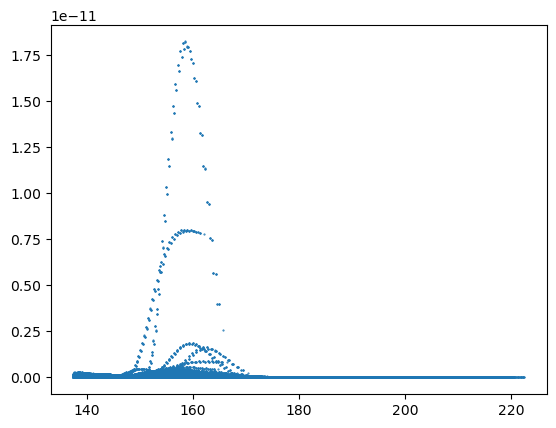

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.plot(1e7/continuum['line_pos'], continuum['A'], '.', markersize=1)

In [6]:
continuum.sort_values(by='A', ascending=False)


,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,up_energy,down_el,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity
2261777,2261777,42853.6620,4.267866e+00,1.919410e-05,B3Sigma-,499,55.0,0.0,-1.0,-1.0,73692.6019,X3Sigma-,21,54.0,0.0,1.0,1.0,30838.9399,7.697513e-28
2205527,2205527,42853.6620,4.266402e+00,1.884180e-05,B3Sigma-,499,54.0,0.0,-1.0,-1.0,73692.6019,X3Sigma-,21,53.0,0.0,1.0,1.0,30838.9399,7.556227e-28
2178389,2178389,42853.6620,4.266375e+00,1.849596e-05,B3Sigma-,499,53.0,0.0,0.0,0.0,73692.6019,X3Sigma-,21,52.0,0.0,0.0,0.0,30838.9399,7.417533e-28
2177798,2177798,43000.6514,4.256875e+00,1.826616e-05,B3Sigma-,499,53.0,0.0,-1.0,-1.0,73597.5950,X3Sigma-,21,52.0,0.0,1.0,1.0,30596.9436,8.018999e-28
2121689,2121689,43000.6514,4.255300e+00,1.791811e-05,B3Sigma-,499,52.0,0.0,-1.0,-1.0,73597.5950,X3Sigma-,21,51.0,0.0,1.0,1.0,30596.9436,7.866201e-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1153248,1153248,59081.1820,4.735305e-37,4.319667e-43,B3Sigma-,224,29.0,0.0,0.0,0.0,60161.5141,X3Sigma-,0,28.0,0.0,1.0,1.0,1080.3321,1.063610e-60
1320152,1320152,58759.5425,4.704698e-37,4.954150e-43,B3Sigma-,223,33.0,0.0,0.0,0.0,60176.0140,X3Sigma-,0,32.0,0.0,1.0,1.0,1416.4715,1.075031e-60
1487636,1487636,59160.4803,4.673316e-37,5.397457e-43,B3Sigma-,249,37.0,0.0,0.0,0.0,60958.0322,X3Sigma-,0,36.0,0.0,1.0,1.0,1797.5519,1.028169e-60
1487475,1487475,58661.6061,4.595276e-37,5.443884e-43,B3Sigma-,233,37.0,0.0,0.0,0.0,60459.1580,X3Sigma-,0,36.0,0.0,1.0,1.0,1797.5519,1.028268e-60


In [ ]:
# # NEW CODE FOR MALFORMED ROWS database
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assume 'continuum' is your main dataframe
# # working_df = continuum.copy() # Good practice to work on a copy

# # ==========================================
# # PASS 1: Calculate Widths for Valid Levels
# # ==========================================

# # 1. Isolate the "Truth": Get only valid v entries (ignore -1)
# # We use the same 'subset' logic you had (e.g., J=0 or J=108) to define the energy curve
# valid_subset = continuum[(continuum['up_v'] != -1) & (continuum['up_J'] == 108)].copy()

# # 2. Group and Aggregate (Same as your previous valid logic)
# vib_levels = valid_subset.groupby('up_v')['up_energy'].min().reset_index()
# vib_levels = vib_levels.sort_values('up_v')

# v_list = vib_levels['up_v'].tolist()
# e_list = vib_levels['up_energy'].tolist()

# # 3. Compute Smoothing Widths (n+1) - (n)
# smoothing_widths = []
# count = len(e_list)

# for i in range(count):
#     if i < count - 1:
#         diff = e_list[i+1] - e_list[i]
#         smoothing_widths.append(diff)
#     else:
#         # Default last entry to previous width
#         if len(smoothing_widths) > 0:
#             smoothing_widths.append(smoothing_widths[-1])
#         else:
#             smoothing_widths.append(0.0)

# # 4. Create the Map
# width_map = dict(zip(v_list, smoothing_widths))

# # 5. Apply Map to DataFrame (Pass 1 Application)
# # This assigns widths ONLY to rows where up_v is valid. 
# # Rows with up_v = -1 will get NaN (Not a Number).
# continuum['smoothing_widths'] = continuum['up_v'].map(width_map)

# # ==========================================
# # PASS 2: Energy Sort & Forward Fill
# # ==========================================

# # 1. Sort by Energy
# # This places malformed rows (v=-1) directly after the valid row 
# # that has slightly lower energy (their likely true vibrational level).
# continuum = continuum.sort_values(by='up_energy')

# # 2. Forward Fill (The "Assign Previous Valid" Step)
# # This takes the valid width from the row above and pastes it into the NaN rows below.
# continuum['smoothing_widths'] = continuum['smoothing_widths'].ffill()

# # 3. (Optional) Backward Fill for safety
# # If the very first rows in the database (lowest energy) are malformed (v=-1),
# # they won't have a "previous" value to copy. We backfill to catch these edge cases.
# continuum['smoothing_widths'] = continuum['smoothing_widths'].bfill()

# # --- Verification ---
# print("Processing Complete.")

# # Check a snippet: Find a spot where we likely transitioned from a valid v to a -1
# # We look for rows where up_v is -1 to see if they successfully got a width
# malformed_sample = continuum[continuum['up_v'] == -1].head()

# if not malformed_sample.empty:
#     print("\nSample of corrected 'up_v = -1' rows:")
#     print(malformed_sample[['up_v', 'up_energy', 'smoothing_widths']])
# else:
#     print("\nNo 'up_v = -1' rows found in snippet.")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ──────────────────────────────────────────────
# Data extraction (unchanged physics)
# ──────────────────────────────────────────────
subset = continuum[continuum['up_J'] == 108].copy()

vib_levels = subset.groupby('up_v')['up_energy'].min().reset_index()
vib_levels = vib_levels.sort_values('up_v')

v_list = vib_levels['up_v'].tolist()
e_list = vib_levels['up_energy'].tolist()

energy_dict = dict(zip(v_list, e_list))

print(f"Max up_v: {max(v_list)}")
print(f"Min up_v: {min(v_list)}")
print(f"Number of levels found: {len(v_list)}")
print("-" * 30)
print("Dictionary of {v: Energy}:")
print(list(energy_dict.items())[:10])  # Print first 10 entries for brevity

# ──────────────────────────────────────────────
# Compute smoothing widths (unchanged)
# ──────────────────────────────────────────────
smoothing_widths = []
count = len(e_list)

for i in range(count):
    if i < count - 1:
        diff = e_list[i+1] - e_list[i]
        smoothing_widths.append(diff)
    else:
        if len(smoothing_widths) > 0:
            smoothing_widths.append(smoothing_widths[-1])
        else:
            smoothing_widths.append(0.0)

# print("v\tEnergy\tSmoothing Width")
# for v, e, sw in zip(v_list, e_list, smoothing_widths):
#     print(f"{v}\t{e:.2f}\t{sw:.2f}")

# width_map = dict(zip(v_list, smoothing_widths))
# print(width_map)

# ──────────────────────────────────────────────
# Plot (merged, twin axis, styled)
# ──────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
})

FIGSIZE = (5, 3)

LW = 1.4
MS = 4

fig, ax1 = plt.subplots(figsize=FIGSIZE)

# --- Left axis: Energy ---
ax1.plot(
    v_list, e_list,
    linestyle='--',
    linewidth=LW,
    color='tab:red',
    label='Energy'
)
ax1.set_xlabel(r'Vibrational Quantum Number ($v_{up}$)')
ax1.set_ylabel(r'Energy (cm$^{-1}$)', color='black')

# --- Right axis: Smoothing widths ---
ax2 = ax1.twinx()
# ax2.plot(
#     v_list, smoothing_widths,
#     linestyle='--',
#     linewidth=LW,
#     color='tab:blue',
#     label='Smoothing Width'
# ) 
# plot rolling average of widths for better visualization
window_size = 20
rolling_widths = np.convolve(smoothing_widths, np.ones(window_size)/window_size
, mode='same')
ax2.plot(
    v_list, rolling_widths,
    linestyle='--',
    linewidth=LW,
    color='tab:green',
    label='Smoothing Widths'
)


ax2.set_ylabel(r'Smoothing Width (cm$^{-1}$)', color='black')

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ax1 owns: bottom and left only
ax1.tick_params(which='major', direction='in', length=5,
                top=False, bottom=True, left=True, right=False)
ax1.tick_params(which='minor', direction='in', length=2.5,
                top=False, bottom=True, left=True, right=False)

ax1.xaxis.set_major_locator(MultipleLocator(30))   # major every 20

ax1.xaxis.set_minor_locator(MultipleLocator(10))    # minor every 5 — all integers

ax1.yaxis.set_minor_locator(AutoMinorLocator())    # energy is continuous, fine here

# ax2 owns: top and right
ax2.tick_params(which='major', direction='in', length=5,
                top=True, bottom=False, left=False, right=True)
ax2.tick_params(which='minor', direction='in', length=2.5,
                top=True, bottom=False, left=False, right=True)
ax2.yaxis.set_minor_locator(AutoMinorLocator())

ax1.grid(True, ls='--', alpha=0.25)
ax1.set_xlim(30, 210)
ax1.set_ylim(55000, 70000)

ax2.set_ylim(20, 100)
# --- Combined legend ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=True, fontsize=9)
plt.savefig("cont_1.svg", format="svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
# insert smoothing widths back into continuum dataframe
continuum['smoothing_widths'] = continuum['up_v'].map(width_map)
continuum[continuum['up_v'] == 1]

In [ ]:
continuum[continuum['up_v'] == 140]

In [ ]:
continuum_grouped = continuum.groupby(
    ['down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy']
).agg({
    'A': list,
    'line_pos': list,
    'up_energy': list,      # optional, if you want to retain upper state quantum numbers
    'up_J': list,
    'up_v': list,
    'smoothing_widths': list
    # add more columns as needed
}).reset_index()

continuum_grouped

In [ ]:
plt.plot(1e7/continuum['line_pos'], continuum['A'], '.', markersize=1)


In [ ]:
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter
import numpy as np

stats = continuum.groupby('down_v')['A'].agg(
    A_sum='sum',
    A_max='max',
    A_p90=lambda x: x.quantile(0.90)
).reset_index().sort_values('down_v')

fig, ax = plt.subplots(figsize=(4.5, 3.5))

# --- swapped axes ---
ax.scatter(stats['down_v'], stats['A_sum'],
           s=6, color='tab:red', label=r'$\sum A$', zorder=3)
# ax.scatter(stats['down_v'], stats['A_max'],
#            s=6, color='tab:blue', marker='s', label=r'$A_\mathrm{max}$', zorder=3)
# # ax.scatter(stats['down_v'], stats['A_p90'],
#            s=6, color='tab:green', marker='^', label=r'90th percentile', zorder=3)

# log now on Y (since A moved to Y)
# ax.set_yscale('log')
# ax.invert_yaxis()

ax.set_xlabel(r'$v_\mathrm{down}$')
ax.set_ylabel(r'Total Einstein $A$ (s$^{-1}$)')

ax.tick_params(which='major', direction='in', length=5,
               top=True, bottom=True, left=True, right=True)
ax.tick_params(which='minor', direction='in', length=2.5,
               top=True, bottom=True, left=True, right=True)

# ax.set_ylim(1e9, 1e12)

# replace the yaxis minor locator line with:
# ax.yaxis.set_major_locator(LogLocator(base=10, numticks=2))
# ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=15))
# ax.yaxis.set_minor_formatter(NullFormatter())  # ticks but no labels

ax.legend(fontsize=9, frameon=True)
ax.grid(True, ls='--', alpha=0.25)
plt.title("Total radiative rate from a lower level to the continuum")
plt.tight_layout()
plt.savefig("cont_2.svg", format="svg", bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator

# ── Qualitative functions ──────────────────────────────────────────────────

def tdm(R):
    """Qualitative TDM shape matching Qin et al. (2023): peak ~1.16 Å, rapid decay."""
    R = np.atleast_1d(np.array(R, dtype=float))
    r0, s1, s2 = 1.16, 0.022, 0.11
    rise = 1 - np.exp(-40 * (R - 0.92))
    rise = np.clip(rise, 0, None)
    out = np.where(
        R <= r0,
        2.4 * np.exp(-(R - r0)**2 / (2 * s1)) * rise,
        2.4 * np.exp(-(R - r0)**2 / (2 * s2))
    )
    out[R < 0.92] = 0.0
    return out

def psi_v0(R):
    """v=0 X-state: narrow Gaussian at r_e = 1.207 Å."""
    return 1.0 * np.exp(-(R - 1.207)**2 / (2 * 0.038**2))

def psi_v25(R):
    """v=25 X-state: semiclassical oscillatory wavefunction.
    Inner TP ~1.06 Å, outer TP ~2.05 Å."""
    R = np.atleast_1d(np.array(R, dtype=float))
    R1, R2 = 1.06, 2.05
    env = np.where(
        (R >= R1) & (R <= R2),
        np.power(np.clip((R - R1) * (R2 - R), 0, None), 0.18) * 0.55,
        0.0
    )
    phase = 13.5 * (R - R1) - 1.2 * (R - R1)**2
    return env * np.sin(phase)

def psi_cont(R):
    """Schematic continuum wavefunction: oscillates in from inner wall."""
    R = np.atleast_1d(np.array(R, dtype=float))
    env = 0.55 * np.exp(-0.22 * (R - 0.95))
    phase = 16 * (R - 0.95) - 2.5 * (R - 0.95)**2
    out = env * np.sin(phase)
    out[R < 0.95] = 0.0
    return out

# ── Grid ──────────────────────────────────────────────────────────────────

R = np.linspace(0.88, 3.1, 4000)

T   = tdm(R)
P0  = psi_v0(R)
P25 = psi_v25(R)
PC  = psi_cont(R)

# Overlap integrands
OI0  = PC * T * P0  * 0.5
OI25 = PC * T * P25 * 0.5

# ── Colours (edit freely) ──────────────────────────────────────────────────
C_TDM   = '#2E86AB'
C_V0    = '#E63946'
C_V25   = '#7B2D8B'
C_CONT  = '#2A9D4E'
C_OI0   = '#E63946'
C_OI25  = '#7B2D8B'
C_ZONE  = '#AED6F1'   # TDM active zone fill

# ── Figure ────────────────────────────────────────────────────────────────
plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

fig, ax = plt.subplots(figsize=(8, 4))

# TDM active zone shading
ax.axvspan(0.92, 1.42, alpha=0.18, color=C_ZONE, label='TDM active zone', zorder=0)

# # TDM
# ax.fill_between(R, T, alpha=0.15, color=C_TDM, zorder=1)
# ax.plot(R, T, color=C_TDM, lw=1.8, label=r'TDM $\mu(R)$ — Qin et al.\ (2023)', zorder=2)

# Wavefunctions
ax.plot(R, P0,  color=C_V0,  lw=2.0,
        label=r'$\psi_{v=0}(R)$ — amplitude within TDM zone', zorder=3)
ax.plot(R, P25, color=C_V25, lw=1.5,
        label=r'$\psi_{v=25}(R)$ — amplitude extends outside', zorder=3)
ax.plot(R, PC,  color=C_CONT, lw=1.4, ls='--',
        label=r'$\psi_\mathrm{cont}(R)$ — B-state continuum (schematic)', zorder=3)

# Overlap integrands (filled)
ax.fill_between(R, OI0,  alpha=0.38, color=C_OI0,
                label=r'$\psi_\mathrm{cont} \cdot \mu(R) \cdot \psi_{0}$ (large)', zorder=4)
ax.fill_between(R, OI25, alpha=0.25, color=C_OI25,
                label=r'$\psi_\mathrm{cont} \cdot \mu(R) \cdot \psi_{25}$ (small)', zorder=4)

# Zero line
ax.axhline(0, color='k', lw=0.5, alpha=0.4, zorder=0)

# r_e(X) marker
ax.axvline(1.207, color='k', lw=0.8, ls=':', alpha=0.5, zorder=1)
ax.text(1.207, 2.35, r'$r_e(\mathrm{X})=1.207$\,\AA',
        ha='center', va='bottom', fontsize=8.5, color='k', alpha=0.7)

# outer TP annotation for v=25
ax.annotate('', xy=(2.05, 0.04), xytext=(2.05, 0.28),
            arrowprops=dict(arrowstyle='->', color=C_V25, lw=1.0))
ax.text(2.05, 0.31, r'$v{=}25$ outer TP', ha='center', fontsize=8,
        color=C_V25)

# overlap area text labels
ax.text(1.245, 0.41, 'large\noverlap', ha='left', fontsize=8,
        color=C_OI0, fontstyle='italic')
ax.text(1.62, -0.32, 'small\noverlap', ha='left', fontsize=8,
        color=C_OI25, fontstyle='italic')

# TDM zone bracket label
ax.annotate('', xy=(0.92, 2.55), xytext=(1.42, 2.55),
            arrowprops=dict(arrowstyle='<->', color=C_TDM, lw=1.0))
ax.text(1.17, 2.62, 'TDM active', ha='center', fontsize=8, color=C_TDM)

# Axes
ax.set_xlim(0.88, 3.1)
ax.set_ylim(-1.0, 2.75)
ax.set_xlabel(r'Internuclear Distance $R$ [\AA]')
ax.set_ylabel('Amplitude (arb. units)')

ax.tick_params(which='major', direction='in', length=5, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=2.5, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.legend(fontsize=7.5, frameon=True, loc='upper right',
          framealpha=0.9, edgecolor='0.7')

plt.tight_layout()
# plt.savefig('wavefunction_overlap_schematic.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from scipy.interpolate import interp1d

# ─────────────────────────────────────────────────────────────────
# 1. Hardcoded Data
# ─────────────────────────────────────────────────────────────────

X_data = [
    [0.9, 65911.8541], [0.95, 39807.05865], [1.0, 22411.47015], [1.05, 11227.90205],
    [1.1, 4571.005825], [1.125, 2524.181975], [1.15, 1152.24375], [1.175, 352.47685],
    [1.207, 0.0], [1.25, 485.698175], [1.3, 2009.293625], [1.35, 4265.27715],
    [1.4, 6987.864525], [1.5, 13078.9542], [1.6, 19254.9807], [1.7, 24997.3246],
    [1.8, 29973.04233], [2.0, 37146.5827], [2.2, 40379.8884], [2.4, 41395.39923],
    [2.6, 41701.56685], [2.8, 41831.27658], [3.0, 41864.4173], [6.0, 42021.5614]
]
X_r, X_energy = np.array(list(zip(*X_data)))

B_data = [
    [0.89816821, 111382.7063], [0.924758716, 95333.85858], [0.962773291, 86612.17254],
    [1.014772503, 77894.42584], [1.050324995, 76214.29978], [1.113748277, 74823.71479],
    [1.155702186, 74835.53279], [1.198148513, 73439.0388], [1.219617885, 72036.63581],
    [1.248571991, 69227.89049], [1.27053378, 66417.1755], [1.292298602, 64169.78531],
    [1.301324503, 60154.4774], [1.317880795, 59329.11028], [1.324503311, 58198.96343],
    [1.337748344, 57243.01756], [1.350993377, 56156.63691], [1.370860927, 55287.9355],
    [1.38410596, 54418.94616], [1.394039735, 53593.2911], [1.410596026, 53072.27181],
    [1.437086093, 52160.38007], [1.456953642, 51552.54823], [1.476821192, 51031.67291],
    [1.506622517, 50554.70775], [1.533112583, 50294.98992], [1.569536424, 49861.79096],
    [1.625827815, 49907.71667], [1.668874172, 50083.5013], [1.708609272, 50302.62021],
    [1.745033113, 50608.55168], [1.784768212, 51262.45321], [1.847682119, 51873.88425],
    [1.887417219, 52484.30752], [1.927152318, 52920.81774], [1.963576159, 53444.14051],
    [2.009933775, 53967.89519], [2.049668874, 54404.40541], [2.105960265, 54928.592],
    [2.162251656, 55496.25684], [2.221854305, 55933.63087], [2.28807947, 56240.85805],
    [2.377483444, 56592.57126], [2.450331126, 56856.60812], [2.523178808, 57033.68845],
    [2.582781457, 57253.67118], [2.668874172, 57474.80564], [2.728476821, 57477.39706],
    [2.798013245, 57567.37691], [2.867549669, 57613.87849], [2.937086093, 57703.85834],
    [2.988410596, 57727.82897], [3.0, 57728.82897], [3.8, 57728.82897]
]

B3Sigma_minus_subset = [
    (1.1, 100000.0), (1.199608611, 73661.65252), (1.223091977, 70244.79602),
    (1.238747554, 67055.72996), (1.26223092, 64550.0352), (1.293542074, 61588.75958),
    (1.324853229, 58855.27438), (1.363992172, 56349.57962), (1.410958904, 54071.6753),
    (1.457925636, 51565.98053), (1.544031311, 50199.23794), (1.6042, 49793.28),
    (1.700587084, 50199.23794), (1.818003914, 51110.39967), (1.927592955, 52477.14227),
    (1.998043053, 53616.09443), (2.13111546, 54755.04659), (2.272015656, 56121.78919),
    (2.412915851, 57032.95092), (2.53816047, 57146.84614), (2.647749511, 57488.53179),
    (2.741682975, 57488.53179), (2.866927593, 57716.32222), (2.984344423, 57488.53179),
    (3.093933464, 57488.53179), (3.266144814, 57488.53179), (3.383561644, 57488.53179),
    (3.532289628, 57602.427), (3.649706458, 57716.32222), (3.798434442, 57716.32222),
    (3.939334638, 57830.21744),
]

B_r, B_energy = np.array(list(zip(*B_data)))
B_r_2, B3Sigma_e = np.array(list(zip(*B3Sigma_minus_subset)))

TDM_Qin_data = [
    [0.975087413, 0.323927849], [0.988199301, 0.423412488], [1.001311189, 0.499200444],
    [1.014423077, 0.58920641], [1.024912587, 0.683959997], [1.035402098, 0.78582259],
    [1.045891608, 0.882945846], [1.061625874, 0.968204189], [1.066870629, 1.034538329],
    [1.074737762, 1.110342856], [1.083916084, 1.195621914], [1.090472028, 1.27616992],
    [1.100961538, 1.347226825], [1.111451049, 1.441980413], [1.121940559, 1.522515991],
    [1.13243007, 1.622008915], [1.140297203, 1.712031452], [1.145541958, 1.783104928],
    [1.156031469, 1.806768468], [1.171765734, 1.778282736], [1.184877622, 1.754544626],
    [1.213723776, 1.754453485], [1.238636364, 1.721199417], [1.258304196, 1.692701256],
    [1.280594406, 1.647607132], [1.308129371, 1.588278428], [1.357954545, 1.483855599],
    [1.410402098, 1.384163822], [1.460227273, 1.289219667], [1.516608392, 1.191885129],
    [1.571678322, 1.101663739], [1.61756993, 1.018580353], [1.66215035, 0.947349451],
    [1.698863636, 0.890361416], [1.730332168, 0.833389951], [1.767045455, 0.771662579],
    [1.810314685, 0.688587479], [1.853583916, 0.610251715], [1.90472028, 0.515303417],
    [1.941433566, 0.455945713], [1.995192308, 0.368098134], [2.045017483, 0.287371988],
    [2.118444056, 0.199462268], [2.189248252, 0.135257515], [2.252185315, 0.09714397],
    [2.294143357, 0.0], [2.317744755, 0.0], [2.336101399, 0.0], [2.354458042, 0.0],
    [2.401660839, 0.0], [2.438374126, 0.0], [2.472465035, 0.0], [2.538024476, 0.0],
    [2.55, 0.0], [2.58, 0.0], [3.0, 0.0]
]
TDM_Qin_r, TDM_Qin_mu = np.array(list(zip(*TDM_Qin_data)))

TDM_Friedman_data = [
    [0.751968504, 0.676886792], [0.775590551, 0.676886792], [0.796587927, 0.676886792],
    [0.833333333, 0.676886792], [0.898950131, 0.676886792], [0.959317585, 0.676886792],
    [0.927821522, 0.676886792], [0.988188976, 0.686320755], [1.011811024, 0.70990566],
    [1.032808399, 0.752358491], [1.043307087, 0.79009434], [1.059055118, 0.837264151],
    [1.066929134, 0.875], [1.07480315, 0.941037736], [1.085301837, 0.988207547],
    [1.093175853, 1.058962264], [1.098425197, 1.110849057], [1.103674541, 1.214622642],
    [1.106299213, 1.271226415], [1.11023622, 1.323113208], [1.111548556, 1.370283019],
    [1.114173228, 1.424528302], [1.1167979, 1.488207547], [1.118110236, 1.533018868],
    [1.119422572, 1.629716981], [1.122047244, 1.738207547], [1.12335958, 1.841981132],
    [1.124671916, 1.891509434], [1.125984252, 1.943396226], [1.127296588, 1.995283019],
    [1.12992126, 2.101415094], [1.132545932, 2.143867925], [1.135170604, 2.240566038],
    [1.137795276, 2.299528302], [1.143044619, 2.337264151], [1.161417323, 2.375],
    [1.174540682, 2.351415094], [1.187664042, 2.323113208], [1.206036745, 2.275943396],
    [1.217847769, 2.228773585], [1.234908136, 2.195754717], [1.25328084, 2.148584906],
    [1.266404199, 2.106132075], [1.282152231, 2.068396226], [1.297900262, 2.035377358],
    [1.311023622, 1.997641509], [1.329396325, 1.95990566], [1.347769029, 1.91745283],
    [1.360892388, 1.884433962], [1.379265092, 1.841981132], [1.397637795, 1.804245283],
    [1.416010499, 1.771226415], [1.426509186, 1.747641509], [1.442257218, 1.728773585],
    [1.452755906, 1.695754717], [1.465879265, 1.672169811], [1.484251969, 1.643867925],
    [1.5, 1.610849057], [1.520997375, 1.573113208], [1.549868766, 1.516509434],
    [1.602362205, 1.431603774], [1.667979003, 1.318396226], [1.715223097, 1.233490566],
    [1.893700787, 0.950471698], [1.796587927, 1.091981132], [1.998687664, 0.827830189],
    [2.106299213, 0.705188679], [2.18503937, 0.634433962], [2.245406824, 0.577830189],
    [2.326771654, 0.516509434], [2.405511811, 0.464622642], [2.494750656, 0.410377358],
    [2.536745407, 0.379716981], [2.589238845, 0.356132075], [2.654855643, 0.327830189],
    [2.723097113, 0.294811321], [2.780839895, 0.271226415], [2.817585302, 0.257075472],
    [2.859580052, 0.242924528], [2.901574803, 0.233490566], [2.954068241, 0.214622642],
    [2.998687664, 0.200471698]
]
TDM_Friedman_r, TDM_Friedman_mu = np.array(list(zip(*TDM_Friedman_data)))

# Equilibrium points
x_min_idx = np.argmin(X_energy)
b_min_idx = np.argmin(B_energy)
X_re, X_emin = X_r[x_min_idx], X_energy[x_min_idx]
B_re, B_emin = B_r[b_min_idx], B_energy[b_min_idx]


# ─────────────────────────────────────────────────────────────────
# 2. Derived quantities
# ─────────────────────────────────────────────────────────────────
 
x_min_idx = np.argmin(X_energy)
b_min_idx = np.argmin(B_energy)
X_re, X_emin = X_r[x_min_idx], X_energy[x_min_idx]
B_re, B_emin = B_r[b_min_idx], B_energy[b_min_idx]
 
delta_re = B_re - X_re  # Å
 
# --- Classical turning points for v=0 (E = 749 cm⁻¹ above X minimum) ---
E_v0 = 749.0  # cm⁻¹
 
# Left branch: r < X_re, energy decreasing as r decreases
X_left_r = X_r[X_r <= X_re]
X_left_e = X_energy[X_r <= X_re]
# Interpolate (energy is monotonically decreasing toward minimum from left)
f_left = interp1d(X_left_e[::-1], X_left_r[::-1])  # flip so energy is increasing
r_left = float(f_left(E_v0))
 
# Right branch: r > X_re
X_right_r = X_r[X_r >= X_re]
X_right_e = X_energy[X_r >= X_re]
f_right = interp1d(X_right_e, X_right_r)
r_right = float(f_right(E_v0))
 
print(f"X_re = {X_re:.4f} Å,  B_re = {B_re:.4f} Å,  Δr_e = {delta_re:.4f} Å")
print(f"v=0 turning points: r_left = {r_left:.4f} Å,  r_right = {r_right:.4f} Å")
 
# ─────────────────────────────────────────────────────────────────
# 3. Plotting
# ─────────────────────────────────────────────────────────────────
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
 
# ── Subplot 1: PECs ──────────────────────────────────────────────
 
ax1.plot(X_r, X_energy, label=r'X $^3\Sigma_g^-$', color='blue', linewidth=2, linestyle='-')
ax1.plot(B_r, B_energy, label=r'B $^3\Sigma_u^+$', color='red', linewidth=2, linestyle='-')
ax1.plot(B_r_2, B3Sigma_e, label=r'B $^3\Sigma_g^-$ (subset)', color='orange', linewidth=2, linestyle='-')
 
# Equilibrium scatter points
ax1.scatter([X_re, B_re], [X_emin, B_emin], color='black', s=60, zorder=6)
 
# Vertical dashed lines at equilibrium positions
ax1.axvline(X_re, color='blue', linestyle=':', linewidth=1.2, alpha=0.8)
ax1.axvline(B_re, color='red',  linestyle=':', linewidth=1.2, alpha=0.8)
 
# Double-headed arrow + label for Δr_e
arrow_y = 80000
ax1.annotate(
    '',
    xy=(B_re, arrow_y), xytext=(X_re, arrow_y),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5),
)
ax1.text(
    (X_re + B_re) / 2, arrow_y + 2000,
    f'\u0394$r_e$ = {delta_re:.3f} \u00c5',
    ha='center', va='bottom', fontsize=11, color='black'
)
 
# v=0 horizontal level
ax1.hlines(E_v0, r_left, r_right, colors='blue', linewidth=2.0, label=r'$v=0$ (749 cm$^{-1}$)')
# Small vertical end-caps
cap_h = 800
for r_cap in [r_left, r_right]:
    ax1.vlines(r_cap, E_v0 - cap_h/2, E_v0 + cap_h/2, colors='blue', linewidth=1.5)
 
# Transparent Franck-Condon band (v=0 classical turning points)
ax1.axvspan(r_left, r_right, alpha=0.15, color='steelblue', label='FC region (v=0)')
 
# ── Subplot 2: TDMs ──────────────────────────────────────────────
 
ax2.plot(TDM_Qin_r, TDM_Qin_mu, label='Qin et al. (2023)', color='purple', linestyle='-', linewidth=2)
ax2.plot(TDM_Friedman_r, TDM_Friedman_mu, label='Friedman (1990)', color='green', linestyle='-', linewidth=2)
 
# Mirror the FC band on TDM plot for reference
ax2.axvspan(r_left, r_right, alpha=0.15, color='steelblue', label='FC region (v=0)')
 
# ─────────────────────────────────────────────────────────────────
# 4. Styling
# ─────────────────────────────────────────────────────────────────
 
ax1.set_xlabel('Internuclear Distance [\u00c5]', fontsize=14)
ax1.set_ylabel(r'Energy [cm$^{-1}$]', fontsize=14)
ax1.legend(loc='upper right', fontsize=10)
ax1.tick_params(which='major', direction='in', length=6, top=True, right=True, labelsize=12)
ax1.tick_params(which='minor', direction='in', length=4, top=True, right=True)
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.set_xlim(0.9, 3.6)
ax1.set_ylim(0, 120000)
 
ax2.set_xlabel('Internuclear Distance [\u00c5]', fontsize=14)
ax2.set_ylabel('Transition Dipole Moment (\u03bc) [Debye]', fontsize=14)
ax2.legend(loc='best', fontsize=11)
ax2.tick_params(which='major', direction='in', length=6, top=True, right=True, labelsize=12)
ax2.tick_params(which='minor', direction='in', length=4, top=True, right=True)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.set_xlim(0.9, 3.6)
ax2.set_ylim(0, 2.5)
 
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/O2_PEC_TDM_v2.png', dpi=150, bbox_inches='tight')
# print("Saved.")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d

# ── Assumes these variables already exist in your namespace from your PEC code:
#    X_r, X_energy, B_r, B_energy, B_r_2, B3Sigma_e
#    X_re, X_emin, B_re, B_emin, delta_re
#    r_left, r_right, E_v0   (v=0 turning points already computed)
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Estimate v=25 turning points from actual X PEC ────────────────────────
# Approximate E(v) using O2 X-state spectroscopic constants
# (ωe = 1580.19, ωexe = 11.98 cm⁻¹ — Herzberg 1950)
omega_e   = 1580.19
omega_exe = 11.98
def E_vib(v):
    return omega_e*(v + 0.5) - omega_exe*(v + 0.5)**2

E_v25_rel = E_vib(25) - E_vib(0)   # energy of v=25 relative to v=0
E_v25     = E_v0 + E_v25_rel        # absolute, same reference as PEC

# Turning points for v=25 from X PEC by interpolation
X_left_r  = X_r[X_r <= X_re];  X_left_e  = X_energy[X_r <= X_re]
X_right_r = X_r[X_r >= X_re];  X_right_e = X_energy[X_r >= X_re]
f_left    = interp1d(X_left_e[::-1],  X_left_r[::-1],  bounds_error=False, fill_value='extrapolate')
f_right   = interp1d(X_right_e,       X_right_r,        bounds_error=False, fill_value='extrapolate')
r25_left  = float(f_left(E_v25))
r25_right = float(f_right(E_v25))

# ── 2. B-state dissociation limit (asymptote of B PEC) ───────────────────────
E_diss_B = np.mean(B_energy[-30:])   # average of last 30 points ~ asymptote

# ── 3. Qualitative wavefunction generators ───────────────────────────────────

def wf_bound_v0(R, r_l, r_r, E_offset, amp=1800):
    """Narrow Gaussian at r_e(X). amp in cm⁻¹."""
    sigma = (r_r - r_l) / 5.0
    return E_offset + amp * np.exp(-(R - X_re)**2 / (2 * sigma**2))

def wf_bound_v25(R, r_l, r_r, E_offset, amp=2800):
    """Semiclassical oscillatory wavefunction between turning points."""
    R = np.array(R)
    env = np.where(
        (R >= r_l) & (R <= r_r),
        np.power(np.clip((R - r_l)*(r_r - R), 0, None), 0.18),
        0.0
    )
    n_nodes = 25
    k = n_nodes * np.pi / (r_r - r_l)
    phase = k * (R - r_l)
    return E_offset + amp * env * np.sin(phase)

def wf_continuum(R, E_offset, amp=2200):
    """Oscillates in from inner wall of B state; decays outward (unbound)."""
    R = np.array(R)
    r_inner = 0.7
    env     = amp * np.exp(-1.8 * (R - r_inner))
    phase   = 18*(R - r_inner) - 3.5*(R - r_inner)**2
    out     = E_offset + env * np.sin(phase)
    out[R < r_inner] = E_offset
    return out

# ── 4. R grids ────────────────────────────────────────────────────────────────
R_full = np.linspace(0.90, 3.6, 5000)
R_v0   = np.linspace(r_left,   r_right,   800)
R_v25  = np.linspace(r25_left, r25_right, 1500)
R_cont = np.linspace(0.96,     2.0,       1000)

WF0   = wf_bound_v0(R_v0,   r_left,   r_right,   E_v0)
WF25  = wf_bound_v25(R_v25, r25_left, r25_right, E_v25)
WFC   = wf_continuum(R_cont, E_diss_B + 800)   # just above dissociation

# ── 5. Colours ────────────────────────────────────────────────────────────────
C_X    = '#1a6faf'
C_B    = '#c0392b'
C_Bsub = '#e67e22'
C_V0   = '#1a6faf'
C_V25  = '#8e44ad'
C_CONT = '#27ae60'
C_FC   = 'steelblue'

# ── 6. Figure ─────────────────────────────────────────────────────────────────
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# PECs
ax.plot(X_r,   X_energy, color=C_X,    lw=2.0, label=r'X $^3\Sigma_g^-$')
ax.plot(B_r,   B_energy, color=C_B,    lw=2.0, label=r'B $^3\Sigma_u^+$')
ax.plot(B_r_2, B3Sigma_e,color=C_Bsub, lw=2.0, label=r'B $^3\Sigma_g^-$ (subset)')

# FC zone
ax.axvspan(r_left, r_right, alpha=0.15, color=C_FC, zorder=0,
           label=r'FC region ($v=0$)')

# Dissociation threshold line
ax.axhline(E_diss_B, color='gray', lw=0.8, ls='--', alpha=0.6, zorder=1)
ax.text(3.45, E_diss_B + 500, r'$E_\mathrm{diss}$(B)',
        ha='right', fontsize=9, color='gray', alpha=0.8)

# v=0 wavefunction + horizontal level
ax.hlines(E_v0, r_left, r_right, colors=C_V0, lw=1.2, alpha=0.5, ls=':')
ax.plot(R_v0, WF0, color=C_V0, lw=2.0,
        label=r'$\psi_{v=0}$  (schematic)')
ax.fill_between(R_v0, E_v0, WF0, alpha=0.18, color=C_V0)

# v=25 wavefunction + horizontal level
ax.hlines(E_v25, r25_left, r25_right, colors=C_V25, lw=1.0, alpha=0.5, ls=':')
ax.plot(R_v25, WF25, color=C_V25, lw=1.6,
        label=r'$\psi_{v=25}$  (schematic)')
ax.fill_between(R_v25, E_v25, WF25, alpha=0.15, color=C_V25)

# Continuum wavefunction (above B dissociation)
ax.plot(R_cont, WFC, color=C_CONT, lw=1.5, ls='--',
        label=r'$\psi_{E_\mathrm{cont}}$  (schematic, above $E_\mathrm{diss}$)')

# Equilibrium markers
ax.scatter([X_re, B_re], [X_emin, B_emin], color='k', s=55, zorder=7)

# Δr_e arrow
arrow_y = 82000
ax.annotate('', xy=(B_re, arrow_y), xytext=(X_re, arrow_y),
            arrowprops=dict(arrowstyle='<->', color='k', lw=1.4))
ax.text((X_re + B_re)/2, arrow_y + 1800,
        rf'$\Delta r_e = {delta_re:.3f}$\,\AA',
        ha='center', va='bottom', fontsize=10)

# Outer TP annotation for v=25
ax.annotate('', xy=(r25_right, E_v25 - 1500),
            xytext=(r25_right, E_v25 - 6000),
            arrowprops=dict(arrowstyle='->', color=C_V25, lw=1.0))
ax.text(r25_right + 0.04, E_v25 - 6500,
        r'$v{=}25$ outer TP', fontsize=8.5, color=C_V25, va='top')

# "continuum" label
ax.text(1.85, E_diss_B + 3200, 'continuum\n(unbound)',
        fontsize=8.5, color=C_CONT, ha='center', style='italic')

# ── 7. Styling ────────────────────────────────────────────────────────────────
ax.set_xlim(0.90, 3.6)
ax.set_ylim(-2000, 120000)
ax.set_xlabel(r'Internuclear Distance [\AA]', fontsize=13)
ax.set_ylabel(r'Energy [cm$^{-1}$]', fontsize=13)

ax.tick_params(which='major', direction='in', length=6, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=3, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.legend(loc='upper right', fontsize=9, frameon=True,
          framealpha=0.9, edgecolor='0.7')

plt.tight_layout()
plt.savefig('PEC_wavefunction_overlap_schematic.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d

# ── Assumes in namespace: X_r, X_energy, B_r, B_energy
#    X_re, X_emin, B_re, B_emin, delta_re, r_left, r_right, E_v0
# ─────────────────────────────────────────────────────────────────

# ── 1. v=25 energy and turning points from real X PEC ────────────
omega_e, omega_exe = 1580.19, 11.98
def E_vib(v): return omega_e*(v+0.5) - omega_exe*(v+0.5)**2

E_v25 = X_emin + (E_vib(25) - E_vib(0)) + E_v0

X_left_r  = X_r[X_r <= X_re];  X_left_e  = X_energy[X_r <= X_re]
X_right_r = X_r[X_r >= X_re];  X_right_e = X_energy[X_r >= X_re]
f_left    = interp1d(X_left_e[::-1], X_left_r[::-1], bounds_error=False, fill_value='extrapolate')
f_right   = interp1d(X_right_e,      X_right_r,      bounds_error=False, fill_value='extrapolate')
r25_left  = float(f_left(E_v25))
r25_right = float(f_right(E_v25))
print(f"v=25 TPs: {r25_left:.3f} – {r25_right:.3f} Å,  E={E_v25:.0f} cm-1")

# ── 2. B dissociation limit + continuum energy ───────────────────
E_diss_B = np.mean(B_energy[-50:])
E_cont   = E_diss_B + 2000          # just above threshold — adjust freely
E_cont   = 80000          # just above threshold — adjust freely

# Inner turning point of continuum state on B repulsive wall
B_inner_mask = B_r <= B_re
f_B_repulsive = interp1d(B_energy[B_inner_mask][::-1],
                          B_r[B_inner_mask][::-1],
                          bounds_error=False, fill_value='extrapolate')
                          
r_cont_inner = float(f_B_repulsive(E_cont))


print(f"Continuum inner TP: {r_cont_inner:.3f} Å")

# ── 3. TDM active zone: 80% of the maximum TDM magnitude range, centered on the peak (1.16 Å) — adjust as needed
# find indices where TDM is below 80% of max and exclude those from active zone; then find actual R range from Qin data
TDM_max = max(TDM_Qin_mu)
TDM_threshold = 0.8 * TDM_max
TDM_active_mask = TDM_Qin_mu >= TDM_threshold
TDM_active_r = TDM_Qin_r[TDM_active_mask]
TDM_R_LO = TDM_active_r.min()
TDM_R_HI = TDM_active_r.max()
# TDM_R_LO = 0.92
# TDM_R_HI = 1.73

# ── 4. Qualitative wavefunction generators ───────────────────────

def wf_v0(R, E_off, amp=2200):
    sigma = (r_right - r_left) / 5.5
    return (E_off + amp * np.exp(-(R - X_re)**2 / (2*sigma**2)) ) * 3

def wf_v25(R, r_l, r_r, E_off, amp=3000):
    R = np.asarray(R)
    env = np.where((R >= r_l) & (R <= r_r),
                   np.power(np.clip((R-r_l)*(r_r-R), 0, None), 0.18), 0.0)
    k   = 26 * np.pi / (r_r - r_l)
    return E_off + amp * env * np.sin(k*(R - r_l))

def wf_cont(R, r_inner, E_off, amp=2400):
    """
    Continuum wavefunction: enters from inner classical turning point
    on repulsive B wall (small R) and oscillates toward large R.
    Amplitude tapers slowly — plane-wave-like but finite plot range.
    """
    R   = np.asarray(R)
    env = amp * np.exp(-0.12 * (R - r_inner))   # slow taper outward
    phi = 20*(R - r_inner) - 3.5*(R - r_inner)**2
    out = np.where(R >= r_inner, E_off + env*np.sin(phi), E_off)
    return out

# ── 5. Qualitative TDM for overlap integrand ─────────────────────
def mu_R(R):
    R  = np.asarray(R, dtype=float)
    r0, s1, s2 = 1.16, 0.022, 0.11
    rise = np.clip(1 - np.exp(-40*(R-0.92)), 0, None)
    out  = np.where(R <= r0,
                    np.exp(-(R-r0)**2/(2*s1))*rise,
                    np.exp(-(R-r0)**2/(2*s2)))
    out[R < 0.92] = 0.0
    return out

# ── 6. Evaluation grids ──────────────────────────────────────────
R_v0   = np.linspace(r_left,       r_right,      600)
R_v25  = np.linspace(r25_left,     r25_right,    2000)
R_cont = np.linspace(r_cont_inner, 2.8,          2000)  # rightward from inner TP

WF0  = wf_v0(R_v0,  E_v0) 
WF25 = wf_v25(R_v25, r25_left, r25_right, E_v25)
WFC  = wf_cont(R_cont, r_cont_inner, E_cont)

# Overlap integrand amplitudes (unitless, for bottom panel)
R_oi   = np.linspace(0.92, 2.8, 4000)
pc     = wf_cont(R_oi, r_cont_inner, 0, amp=1.0)
p0     = np.exp(-(R_oi - X_re)**2 / (2*((r_right-r_left)/5.5)**2))
env25  = np.where((R_oi >= r25_left) & (R_oi <= r25_right),
                  np.power(np.clip((R_oi-r25_left)*(r25_right-R_oi), 0, None), 0.18), 0.0)
p25    = env25 * np.sin(26*np.pi/(r25_right-r25_left) * (R_oi - r25_left))
mu     = mu_R(R_oi)

OI0  = pc * mu * p0
OI25 = pc * mu * p25

# ── 7. Colours ───────────────────────────────────────────────────
C_X    = '#1a6faf'
C_B    = '#c0392b'
C_V0   = '#1a6faf'
C_V25  = '#8e44ad'
C_CONT = '#27ae60'
C_FC   = 'steelblue'
C_TDM  = "#c46411"

# ── 8. Figure ────────────────────────────────────────────────────
plt.rcParams.update({'font.family': 'serif', 'font.size': 11})
fig = plt.figure(figsize=(7.5, 7.2))
gs  = GridSpec(2, 1, height_ratios=[3, 1.2], hspace=0.38)
ax  = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Top panel ────────────────────────────────────────────────────

# TDM active zone (~80% of max TDM ) - use previous mask here to find actual R range from Qin data

# plot

ax.axvspan(TDM_R_LO, TDM_R_HI, alpha=0.18, color=C_TDM, zorder=0, label='TDM active zone')

# PECs — single B state only
ax.plot(X_r, X_energy, color=C_X, lw=2.0, label=r'X $^3\Sigma_g^-$')
ax.plot(B_r, B_energy, color=C_B, lw=2.0, label=r'B $^3\Sigma_u^+$')

# Dissociation limit
ax.axhline(E_diss_B, color='gray', lw=0.9, ls='--', alpha=0.55)
ax.text(3.45, E_diss_B+900, r'$E_\mathrm{diss}$(B)',
        ha='right', fontsize=9, color='gray')

# FC zone (v=0 classical turning points)
# ax.axvspan(r_left, r_right, alpha=0.13, color=C_FC, zorder=0,
#            label=r'FC region ($v{=}0$)')

# v=0 wavefunction
ax.hlines(E_v0, r_left, r_right, colors=C_V0, lw=1.0, ls=':', alpha=0.6)
ax.plot(R_v0, WF0, color=C_V0, lw=2.2, label=r'$\psi_{v=0}$ (schematic)')
ax.fill_between(R_v0, E_v0, WF0, alpha=0.20, color=C_V0)

# v=25 wavefunction
ax.hlines(E_v25, r25_left, r25_right, colors=C_V25, lw=1.0, ls=':', alpha=0.6)
ax.plot(R_v25, WF25, color=C_V25, lw=1.6, label=r'$\psi_{v=25}$ (schematic)')
ax.fill_between(R_v25, E_v25, WF25, alpha=0.13, color=C_V25)

# Continuum wavefunction: starts at inner TP on B wall, propagates rightward
ax.plot(R_cont, WFC, color=C_CONT, lw=1.6,
        label=r'$\psi_{E_\mathrm{cont}}$ ')
ax.fill_between(R_cont, E_cont, WFC, alpha=0.12, color=C_CONT)

# Continuum arrow showing propagation direction
ax.annotate('', xy=(1.9, E_cont+100), xytext=(1.5, E_cont+100),
            arrowprops=dict(arrowstyle='->', color=C_CONT, lw=1.1))
ax.text(2.05, E_cont+1000, 'propagates\nrightward →',
        fontsize=7.5, color=C_CONT, ha='left', style='italic')

# Equilibrium markers
ax.scatter([X_re, B_re], [X_emin, B_emin], color='k', s=55, zorder=7)

# Δr_e arrow
arrow_y = 85000
ax.annotate('', xy=(B_re, arrow_y), xytext=(X_re, arrow_y),
            arrowprops=dict(arrowstyle='<->', color='k', lw=1.4))
ax.text((X_re+B_re)/2, arrow_y+1800,
        rf'$\Delta r_e = {delta_re:.3f}$\,\AA',
        ha='center', va='bottom', fontsize=9.5)

# v=25 outer TP label
ax.annotate('', xy=(r25_right, E_v25-1000),
            xytext=(r25_right+0.05, E_v25-6500),
            arrowprops=dict(arrowstyle='->', color=C_V25, lw=0.9))
ax.text(r25_right+0.07, E_v25-7200,
        r'$v{=}25$ outer TP', fontsize=8, color=C_V25, va='top')

# TDM bracket
ax.annotate('', xy=(TDM_R_LO, 100000), xytext=(TDM_R_HI, 100000),
            arrowprops=dict(arrowstyle='<->', color=C_TDM, lw=1.2))
ax.text((TDM_R_LO+TDM_R_HI)/2, 105000,
        r'(${\sim}80\%$ TDM range)',
        ha='center', fontsize=8, color=C_TDM)

ax.set_xlim(0.90, 3.6)
ax.set_ylim(-2000, 116000)
ax.set_ylabel(r'Energy [cm$^{-1}$]', fontsize=12)
ax.tick_params(which='major', direction='in', length=5, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=2.5, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc='upper right', fontsize=8, frameon=True,
          framealpha=0.92, edgecolor='0.7', ncol=2)

# ── Bottom panel: overlap integrands ─────────────────────────────
ax2.fill_between(R_oi, OI0,  alpha=0.45, color=C_V0,
                 label=r'$\psi_\mathrm{cont}\!\cdot\!\mu(R)\!\cdot\!\psi_{0}$ — large')
ax2.fill_between(R_oi, OI25, alpha=0.30, color=C_V25,
                 label=r'$\psi_\mathrm{cont}\!\cdot\!\mu(R)\!\cdot\!\psi_{25}$ — small')
ax2.plot(R_oi, OI0,  color=C_V0,  lw=1.2)
ax2.axvspan(TDM_R_LO, TDM_R_HI, alpha=0.18, color=C_TDM, zorder=0, )

ax2.plot(R_oi, OI25, color=C_V25, lw=1.0)
ax2.axhline(0, color='k', lw=0.5, alpha=0.4)
ax2.axvspan(TDM_R_LO, TDM_R_HI, alpha=0.13, color=C_TDM, zorder=0)
# Also print magnitude ofoverlap integral within the shaded TDM active zone, using trapezoidal rule on the full R_oi range (not just the TDM active subset)
active_mask_oi = (R_oi >= TDM_R_LO) & (R_oi <= TDM_R_HI)
OI0_integral = np.trapz(OI0[active_mask_oi], R_oi[active_mask_oi])
OI25_integral = np.trapz(OI25[active_mask_oi], R_oi[active_mask_oi])

print(f"Overlap integral (v=0): {OI0_integral:.2e}")
print(f"Overlap integral (v=25): {OI25_integral:.2e}")


ax2.set_xlim(0.90, 3.6)
ax2.set_xlabel(r'Internuclear Distance [\AA]', fontsize=12)
ax2.set_ylabel('Overlap integral\n(arb. units)', fontsize=10)
# also plot TDM active zone same as before



ax2.tick_params(which='major', direction='in', length=5, top=True, right=True)
ax2.tick_params(which='minor', direction='in', length=2.5, top=True, right=True)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.legend(fontsize=9, frameon=True, framealpha=0.92, edgecolor='0.7')

plt.savefig('cont_3.svg', format='svg', bbox_inches='tight')
plt.show()

The monotonic decrease of $\Gamma_v$ with increasing $v_\mathrm{down}$
follows directly from the structure of the dipole matrix element

\begin{equation}
    \langle \psi_{E_\mathrm{cont}} | \mu(R) | \psi_{v} \rangle
    = \int_0^\infty \psi_{E_\mathrm{cont}}(R)\,\mu(R)\,\psi_{v}(R)\;\mathrm{d}R,
\end{equation}

\noindent which was evaluated numerically by \textsc{Duo} on its radial
grid for each continuum--bound pair. The integrand is non-negligible only
where all three factors are simultaneously large: the continuum wavefunction
$\psi_{E_\mathrm{cont}}$ carries its greatest amplitude near the inner
classical turning point of the B state; the TDM $\mu(R)$ of
\citet{Qin2023} peaks near $R \approx 1.16$~\AA\ and decays rapidly at
larger separations (Figure~\ref{fig:tdm}); and the X-state bound wavefunction
$\psi_v$ must have significant amplitude in that same region. The $v = 0$
level, being a near-Gaussian function centred at $r_e(\mathrm{X}) =
1.207$~\AA, satisfies this condition optimally. For increasing
$v_\mathrm{down}$ the outer classical turning point moves progressively
to larger $R$, accumulating amplitude where $\mu(R) \approx 0$. The
matrix element therefore decreases with $v_\mathrm{down}$, and since
$\Gamma_v \propto \sum |\langle \psi_{E_\mathrm{cont}} | \mu(R) |
\psi_v \rangle|^2$, the total radiative coupling inherits the same
monotonic trend. Figure~\ref{fig:schematic} illustrates this argument
qualitatively; all quantitative values reported here are taken from the
\textsc{Duo} calculations.

In [ ]:

down_J_list = continuum_grouped['down_J'].tolist()
down_energy_list = continuum_grouped['down_energy'].tolist()

# Global variables to store energy data (loaded once)
energies_m = None
J_vals = None

def load_energy_data():
    """Load energy levels from database once"""
    global energies_m, J_vals
    if energies_m is None:
        
        
        energies_cm = list(down_energy_list)
        J_vals = list(down_J_list)
        energies_m = [(energy_cm) / 1e-2 for energy_cm in energies_cm]
        print(f"Loaded {len(energies_cm)} energy levels")

def Q(T_Kelvin, batch_size=500, tolerance=1e-5, verbose=False):

    """
    Calculate partition function Q for a given temperature
    
    Parameters:
    T_Kelvin: Temperature in Kelvin
    batch_size: Number of energy levels to process per batch
    tolerance: Convergence tolerance
    verbose: Print convergence information
    
    Returns:
    Q: Partition function value
    """
    # Load data if not already loaded
    load_energy_data()
    
    Q_val = 0.0
    Q_old = []
    
    if verbose:
        print(f"Calculating Q for T = {T_Kelvin} K")
    # Constants
    k_b = 1.380649e-23  # Boltzmann constant in J/K
    h = 6.62607015e-34  # Planck constant in J·s
    c = 299792458       # Speed of light in m/s
    cm_to_m = 1e-2      # Convert cm^-1 to m^-1
    # Loop in batches, convert each batch to Joules, accumulate Q
    for i in range(0, len(energies_m), batch_size):
        batch_m = energies_m[i:i + batch_size]
        batch_J = J_vals[i:i + batch_size]
        
        # Convert from cm^-1 to J: E(J) = E(cm^-1) * 100 * h * c
        batch_joules = [(e) * h * c for e in batch_m]
        
        # Calculate partition function contribution for each energy level
        batch_contribution = [(np.exp(-(e)/(k_b * T_Kelvin))) for e in batch_joules]
        batch_degeneracies = [2*J + 1 for J in batch_J]  # Degeneracy factor for each J
        batch_contribution = [contrib * deg for contrib, deg in zip(batch_contribution, batch_degeneracies)]
        
        batch_sum = sum(batch_contribution)
        
        Q_old.append(Q_val)
        Q_val += batch_sum
        
        # Check for convergence
        if abs(Q_val - Q_old[-1]) < tolerance:
            
            if verbose:
                print(f"Converged after batch {len(Q_old)}")
            break
    
    if verbose:
    
        print(f"Final Q = {Q_val:.6f}")


    
    return Q_val


In [ ]:
Q(4000)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# 1. Full data from table (ExoMol/ESA)
exomol_T = np.array([
    50, 100, 150, 200, 298.15, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 
    3000, 4000, 5000, 6000, 7000, 8000, 9000
], dtype=float)

exomol_Q = np.array([
    36.97, 73.45, 109.9, 146.4, 218.2, 219.6, 293.7, 369.9, 449.8, 534.2, 623.9, 
    719.4, 820.9, 2207.0, 4362.0, 7452.0, 11660.0, 17190.0, 24250.0, 33020.0, 
    43650.0
], dtype=float)

# 2. Local styling and comparison
plt.rcParams.update({"font.family": "serif", "font.size": 11})
FIGSIZE = (5.2, 5.2)
LW, MS = 1.2, 3 # this is for line width and marker size in the plot

# Dummy DUO data for example (subset of ExoMol for comparison)
temperatures = exomol_T
q_vals = np.array([Q(float(T)) for T in temperatures])

fig, ax = plt.subplots(figsize=FIGSIZE)

# Plot DUO
ax.plot(temperatures, q_vals, '-o', lw=LW, ms=MS, label='DUO')

# Plot ExoMol
ax.plot(exomol_T, exomol_Q, '--s', lw=LW, ms=MS, label='ExoMol', alpha=0.7, color='red')

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Q(T)")
ax.set_xlim(0,3000)
ax.set_ylim(0, 5000)
# ax.set_yscale('log')
# ax.set_xscale('log')

ax.tick_params(which='major', direction='in', length=5, top=True, right=True)
ax.grid(True, ls="--", alpha=0.25)
ax.legend(frameon=True, fontsize=8)
plt.savefig('disc_Qcomparison.svg', format = 'svg', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Variable wavelength compute engine

In [ ]:
# Parallel computation of the cross-section
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import threading
from typing import Tuple, List
import time
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K

T = 3000  # Temperature in Kelvin
Q_T = Q(T)  # Partition function at temperature T


def gaussian_lineprofile(nu, nu_nominal, alpha_D):
    """Compute Gaussian line profile"""
    return np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * np.exp(-np.log(2) * (nu - nu_nominal)**2 / alpha_D**2)

def process_transition_chunk_vectorized(args):
    """
    Process a chunk of transitions using vectorized operations with frequency masking.
    Adapted for variable alpha_D (Doppler width) per transition.
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D_array, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # 1. Reshape inputs for broadcasting
    # nu_grid shape: (1, n_freq)
    nu_grid = nu_range[np.newaxis, :]
    
    # pos_grid shape: (n_trans, 1)
    pos_grid = line_positions[:, np.newaxis]
    
    # alpha_D shape: (n_trans, 1) <--- CRITICAL CHANGE
    # Ensure alpha_D is a column vector so it corresponds to each transition row
    alpha_D_col = alpha_D[:, np.newaxis]
    
    # 2. Variable Cutoff
    # Now cutoff_range is an array of shape (n_trans, 1), not a scalar
    cutoff_range = 3 * alpha_D_col
    
    # 3. Create Distance Matrix
    # Shape: (n_trans, n_freq)
    distances = nu_grid - pos_grid
    
    # 4. Apply frequency masking
    # This now compares the distance matrix against the per-row cutoff_range
    mask = np.abs(distances) <= cutoff_range
    
    # 5. Initialize Gaussian container
    gaussians = np.zeros_like(distances)
    
    # 6. Compute Gaussians only on masked values
    # We must extract the specific alpha_D values that match the valid points in the mask.
    # np.broadcast_to creates a view (cheap) that repeats alpha_D_col across columns.
    # Then [mask] flattens it to match the selected 'distances[mask]'.
    alpha_active = np.broadcast_to(alpha_D_col, mask.shape)[mask]
    dist_active = distances[mask]
    
    # Pre-calculate constants to save operations inside the exponent
    sqrt_ln2_pi = np.sqrt(np.log(2) / np.pi)
    ln2 = np.log(2)
    
    # Vectorized Gaussian formula
    gaussians[mask] = (sqrt_ln2_pi * (1 / alpha_active) * np.exp(-ln2 * (dist_active**2) / (alpha_active**2)))
    
    # 7. Weight by intensities and sum
    # intensities shape: (n_trans, 1)
    weighted = gaussians * intensities[:, np.newaxis]
    
    # Sum down the columns (collapsing all transitions into the single spectrum)
    local_cross_section = np.sum(weighted, axis=0)
    
    return local_cross_section

def process_transition_chunk(args):
    """
    Process a chunk of transitions with frequency masking and accumulate contributions
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_Ds, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    
    # Process each transition in this chunk
    for central_position, intensity, alpha_D in zip(line_positions, intensities, alpha_Ds):
        # Apply frequency masking: only compute within 5 Doppler widths
        cutoff_range = 3 * alpha_D
        mask = (nu_range >= central_position - cutoff_range) & (nu_range <= central_position + cutoff_range)
        
            
        # Compute Gaussian contribution only for masked region
        masked_nu = nu_range[mask]
        contribution = intensity * gaussian_lineprofile(masked_nu, central_position, alpha_D)
        
        # Add contribution to local cross-section
        local_cross_section[mask] += contribution
    
    return local_cross_section

def compute_cross_section_optimized(line_positions, intensities, nu_range, alpha_D, 
                                  num_chunks=4, num_threads=None):
    """
    Compute cross-section using chunking and multithreading with frequency masking
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D: Doppler width parameter
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section: final cross-section array
    """
    total_transitions = len(line_positions)
    # print(f"Processing {total_transitions:,} transitions in {num_chunks} chunks")
    
    # Initialize final cross-section array
    cross_section = np.zeros_like(nu_range)
    
    # Calculate chunk size
    chunk_size = total_transitions // num_chunks
    
    # Process each chunk
    for chunk_idx in range(num_chunks):
        start_idx = chunk_idx * chunk_size
        if chunk_idx == num_chunks - 1:  # Last chunk gets remaining transitions
            end_idx = total_transitions
        else:
            end_idx = (chunk_idx + 1) * chunk_size
        
        chunk_line_positions = line_positions[start_idx:end_idx]
        chunk_intensities = intensities[start_idx:end_idx]
        chunk_alpha_D = alpha_D[start_idx:end_idx]

        # print(f"Processing chunk {chunk_idx + 1}/{num_chunks} "
        #       f"({len(chunk_line_positions):,} transitions)")
        
        # Further divide chunk for multithreading
        if num_threads is None:
            import os
            num_threads = os.cpu_count()
        
        thread_chunk_size = len(chunk_line_positions) // num_threads
        thread_args = []
        
        for thread_idx in range(num_threads):
            thread_start = thread_idx * thread_chunk_size
            if thread_idx == num_threads - 1:  # Last thread gets remaining
                thread_end = len(chunk_line_positions)
            else:
                thread_end = (thread_idx + 1) * thread_chunk_size
            
            if thread_start < len(chunk_line_positions):
                thread_args.append((
                    chunk_line_positions[thread_start:thread_end],
                    chunk_intensities[thread_start:thread_end],
                    nu_range,
                    chunk_alpha_D[thread_start:thread_end],
                    thread_idx
                ))
        
        # Execute multithreaded computation for this chunk
        start_time = time.time()
        with ThreadPoolExecutor(max_workers=num_threads) as executor:
            results = list(executor.map(process_transition_chunk_vectorized, thread_args))
        
        # Accumulate results from all threads
        for result in results:
            cross_section += result
        
        chunk_time = time.time() - start_time
        # print(f"Chunk {chunk_idx + 1} completed in {chunk_time:.2f}s")
    
    return cross_section

def compute_cross_section_batch_optimized(line_positions, intensities, nu_range, alpha_D_list, 
                                        num_chunks=4, num_threads=None):
    """
    Compute cross-sections for multiple alpha_D values using optimized approach
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D_list: list of Doppler width parameters
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section_list: list of cross-section arrays
    """
    cross_section_list = []
    
    # print(f"\nProcessing alpha_D = {alpha_D} ({i+1}/{len(alpha_D_list)})")
    start_time = time.time()
    

    cross_section = compute_cross_section_optimized(
        line_positions, intensities, nu_range, alpha_D_list, 
        num_chunks, num_threads
    )
    
    cross_section_list.append(cross_section)
    
    total_time = time.time() - start_time
    # print(f"Alpha_D = {alpha_D} completed in {total_time:.2f}s")
    
    return cross_section_list

# Example usage with your data
def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks =4):
    # Set up frequency range
    
    
    n_transitions = len (intensities)  # 14 million transitions
    
    print(f"Starting computation with {len(line_positions):,} transitions")
    print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm⁻¹")
    print (f"alpha_d max to min {max(alpha_D_list)} to {min(alpha_D_list)}")
    
    # Run optimized computation
    start_time = time.time()
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions, intensities, nu_range, alpha_D_list,
        num_chunks, num_threads=None  # Auto-detect thread count
    )
    
    total_time = time.time() - start_time
    print(f"\nTotal computation time: {total_time:.2f}s")
    print(f"Cross-section shapes: {[cs.shape for cs in cross_section_list]}")
    
    return cross_section_list





if __name__ == "__main__":
    # alpha_D_list = [300,1500, 3000, 5000] 
    alpha_D_list = [0.003, 3,30] 
    alpha_D_list = [30,300] 
    alpha_D_list = [15] 
    alpha_D_list = [30,150] 
    alpha_D_list = [1] 

    nu_range = np.linspace(1e7/180, 1e7/100, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/550, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/750, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/600, 1e7/90, 6000)  # in cm⁻¹
    nu_range = np.linspace(1e7/200, 1e7/100, 2000)  # in cm⁻¹
    continuum['Intensity'] = 0
    continuum['Intensity'] = continuum['A'] * (2 * continuum['up_J'] + 1) * np.exp(-(h*c*(continuum['down_energy']-2.86)/(k_B * T)))  / (8.0 * np.pi*c * continuum['line_pos']**(2) * Q_T)
    

    df = continuum.sort_values(by='line_pos', ascending=True)
    
    line_positions = df['line_pos'].values
    intensities = df['Intensity'].values
    alpha_D_list = df['smoothing_widths'].values
    
    cross_section_list = []
    # CALLING THE MAIN CROSS-SECTION FUNCTION:
    cross_section_list = main(alpha_D_list, nu_range, line_positions, intensities, 200)
    
    
    # doing 4 chunks at this time, can decrease if each "list" is smaller or larger, remember that each "chunk" is then parallelized, so chunks are really number of passes

In [ ]:
print(len(cross_section_list[0]))
len(nu_range)

variable_width_cs = cross_section_list[0]

In [ ]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import io

def plot_exomol_o2_cross_section(temperature):
    """
    Fetches, parses, and plots O2 photodissociation cross-sections
    from ExoMol for a given temperature.
    """
    # 1. Construct the URL for the desired temperature
    url = f"https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__{temperature}__0__0.1.photo"
    print(f"Fetching data for T = {temperature} K from {url}")

    try:
        # 2. Fetch the data
        response = requests.get(url)
        response.raise_for_status()  # Raises an exception for bad status codes (404, 500, etc.)

        # 3. Use io.StringIO to treat the text content as a file in memory
        #    The data is whitespace-delimited.
        data_file = io.StringIO(response.text)

        # 4. Load the data directly into NumPy arrays
        #    The first column is wavelength (nm), the second is cross-section (cm^2)
        wavelength, cross_section = np.loadtxt(data_file, unpack=True)
        
        # 5. Plot for validation
        # plt.style.use('seaborn-v0_8-whitegrid')
        # fig, ax = plt.subplots(figsize=(10, 6))

        # ax.plot(wavelength, cross_section)

        # ax.set_xlabel('Wavelength (nm)')
        # ax.set_ylabel(r'Cross Section ($cm^{2} \, molecule^{-1}$)')
        # ax.set_title('Absorption Cross Section vs Wavelength (T = 3000 K)')
        # ax.grid(True, which="both", ls="--")
        # ax.set_xlim(130, 180)
        # ax.set_ylim(1e-20, 0.5e-16)
        # ax.set_yscale('log') # Cross-sections often span many orders of magnitude

        # plt.show()
        return wavelength, cross_section

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- Run the function for a specific temperature ---
plot_exomol_o2_cross_section(temperature=3000)

In [ ]:
import duckdb
import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import time

# Load validation data
validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Yoshino_2005.csv')
validation_x = validation_data.iloc[:, 0]
validation_y = validation_data.iloc[:, 1]

validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Lu_2010.csv')
validation_x_3 = validation_data.iloc[:, 0]
validation_y_3 = validation_data.iloc[:, 1]

# ExoMol data
validation_x_2, validation_y_2 = plot_exomol_o2_cross_section(T)

# === Clean Plot ===
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=12)
ax.set_xlim(130, 175)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

# Plot model spectrum
# ax.plot(1e7 / nu_range, variable_width_cs, label=r'Duo, $\alpha_D$ = variable $cm^{-1}$', linestyle='-', color='tab:blue')

# Validation data with error bars
ax.errorbar(validation_x, validation_y, yerr=0.3 * validation_y, fmt='o', markersize=4, markerfacecolor='none', color='black', label='Yoshino (2005)')
ax.plot(validation_x_2, validation_y_2, color='red', label='Exomol database', linestyle='--')

# Ticks and grid
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, linestyle='--', alpha=0.5)

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize=9)
plt.savefig('cont_4.svg', format = 'svg', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Constant $\alpha_D$ compute engine

In [ ]:
# Parallel computation of the cross-section
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import threading
from typing import Tuple, List
import time
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K

T = 3000  # Temperature in Kelvin
Q_T = Q(T)  # Partition function at temperature T


def gaussian_lineprofile(nu, nu_nominal, alpha_D):
    """Compute Gaussian line profile"""
    return np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * np.exp(-np.log(2) * (nu - nu_nominal)**2 / alpha_D**2)

def process_transition_chunk_vectorized(args):
    """
    Process a chunk of transitions using vectorized operations with frequency masking
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    cutoff_range = 3 * alpha_D
    
    # Vectorized computation for this chunk
    # Create 2D arrays: (n_transitions, n_frequencies)
    nu_grid = nu_range[np.newaxis, :]  # Shape: (1, n_freq)
    pos_grid = line_positions[:, np.newaxis]  # Shape: (n_trans, 1)
    
    # Apply frequency masking: only compute within cutoff range
    mask = np.abs(nu_grid - pos_grid) <= cutoff_range
    
    # Compute Gaussian contributions only where mask is True
    distances = nu_grid - pos_grid
    gaussians = np.zeros_like(distances)
    
    # Only compute Gaussian where mask is True (keeps your masking logic)
    gaussians[mask] = (np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * 
                      np.exp(-np.log(2) * distances[mask]**2 / alpha_D**2))
    
    # Weight by intensities and sum along transition axis
    weighted = gaussians * intensities[:, np.newaxis]
    local_cross_section = np.sum(weighted, axis=0)
    
    return local_cross_section

def process_transition_chunk(args):
    """
    Process a chunk of transitions with frequency masking and accumulate contributions
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    
    # Process each transition in this chunk
    for central_position, intensity in zip(line_positions, intensities):
        # Apply frequency masking: only compute within 5 Doppler widths
        cutoff_range = 3 * alpha_D
        mask = (nu_range >= central_position - cutoff_range) & (nu_range <= central_position + cutoff_range)
        
            
        # Compute Gaussian contribution only for masked region
        masked_nu = nu_range[mask]
        contribution = intensity * gaussian_lineprofile(masked_nu, central_position, alpha_D)
        
        # Add contribution to local cross-section
        local_cross_section[mask] += contribution
    
    return local_cross_section

def compute_cross_section_optimized(line_positions, intensities, nu_range, alpha_D, 
                                  num_chunks=4, num_threads=None):
    """
    Compute cross-section using chunking and multithreading with frequency masking
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D: Doppler width parameter
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section: final cross-section array
    """
    total_transitions = len(line_positions)
    # print(f"Processing {total_transitions:,} transitions in {num_chunks} chunks")
    
    # Initialize final cross-section array
    cross_section = np.zeros_like(nu_range)
    
    # Calculate chunk size
    chunk_size = total_transitions // num_chunks
    
    # Process each chunk
    for chunk_idx in range(num_chunks):
        start_idx = chunk_idx * chunk_size
        if chunk_idx == num_chunks - 1:  # Last chunk gets remaining transitions
            end_idx = total_transitions
        else:
            end_idx = (chunk_idx + 1) * chunk_size
        
        chunk_line_positions = line_positions[start_idx:end_idx]
        chunk_intensities = intensities[start_idx:end_idx]
        
        # print(f"Processing chunk {chunk_idx + 1}/{num_chunks} "
        #       f"({len(chunk_line_positions):,} transitions)")
        
        # Further divide chunk for multithreading
        if num_threads is None:
            import os
            num_threads = os.cpu_count()
        
        thread_chunk_size = len(chunk_line_positions) // num_threads
        thread_args = []
        
        for thread_idx in range(num_threads):
            thread_start = thread_idx * thread_chunk_size
            if thread_idx == num_threads - 1:  # Last thread gets remaining
                thread_end = len(chunk_line_positions)
            else:
                thread_end = (thread_idx + 1) * thread_chunk_size
            
            if thread_start < len(chunk_line_positions):
                thread_args.append((
                    chunk_line_positions[thread_start:thread_end],
                    chunk_intensities[thread_start:thread_end],
                    nu_range,
                    alpha_D,
                    thread_idx
                ))
        
        # Execute multithreaded computation for this chunk
        start_time = time.time()
        with ThreadPoolExecutor(max_workers=num_threads) as executor:
            results = list(executor.map(process_transition_chunk_vectorized, thread_args))
        
        # Accumulate results from all threads
        for result in results:
            cross_section += result
        
        chunk_time = time.time() - start_time
        # print(f"Chunk {chunk_idx + 1} completed in {chunk_time:.2f}s")
    
    return cross_section

def compute_cross_section_batch_optimized(line_positions, intensities, nu_range, alpha_D_list, 
                                        num_chunks=4, num_threads=None):
    """
    Compute cross-sections for multiple alpha_D values using optimized approach
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D_list: list of Doppler width parameters
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section_list: list of cross-section arrays
    """
    cross_section_list = []
    
    for i, alpha_D in enumerate(alpha_D_list):
        # print(f"\nProcessing alpha_D = {alpha_D} ({i+1}/{len(alpha_D_list)})")
        start_time = time.time()
        
        cross_section = compute_cross_section_optimized(
            line_positions, intensities, nu_range, alpha_D, 
            num_chunks, num_threads
        )
        
        cross_section_list.append(cross_section)
        
        total_time = time.time() - start_time
        # print(f"Alpha_D = {alpha_D} completed in {total_time:.2f}s")
    
    return cross_section_list

# Example usage with your data
def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks =4):
    # Set up frequency range
    
    
    n_transitions = len (intensities)  # 14 million transitions
    
    print(f"Starting computation with {len(line_positions):,} transitions")
    print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm⁻¹")
    print(f"Alpha_D values: {alpha_D_list}")
    
    # Run optimized computation
    start_time = time.time()
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions, intensities, nu_range, alpha_D_list,
        num_chunks, num_threads=None  # Auto-detect thread count
    )
    
    total_time = time.time() - start_time
    print(f"\nTotal computation time: {total_time:.2f}s")
    print(f"Cross-section shapes: {[cs.shape for cs in cross_section_list]}")
    
    return cross_section_list




if __name__ == "__main__":
    # alpha_D_list = [300,1500, 3000, 5000] 
    alpha_D_list = [0.003, 3,30] 
    alpha_D_list = [30,300] 
    alpha_D_list = [15] 
    alpha_D_list = [80,160] 

    nu_range = np.linspace(1e7/180, 1e7/100, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/550, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/750, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/600, 1e7/90, 6000)  # in cm⁻¹
    nu_range = np.linspace(1e7/200, 1e7/100, 2000)  # in cm⁻¹
    continuum['Intensity'] = 0
    continuum['Intensity'] = continuum['A'] * (2 * continuum['up_J'] + 1) * np.exp(-(h*c*(continuum['down_energy']-2.86)/(k_B * T)))  / (8.0 * np.pi*c * continuum['line_pos']**(2) * Q_T)
    

    df = continuum.sort_values(by='line_pos', ascending=True)
    
    line_positions = df['line_pos'].values
    intensities = df['Intensity'].values
    

    cross_section_list = []
    # CALLING THE MAIN CROSS-SECTION FUNCTION:
    cross_section_list = main(alpha_D_list, nu_range, line_positions, intensities, 100)
    
    
    # doing 4 chunks at this time, can decrease if each "list" is smaller or larger, remember that each "chunk" is then parallelized, so chunks are really number of passes

In [ ]:
import duckdb
import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import time

# # Load validation data
# validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Yoshino_2005.csv')
# validation_x = validation_data.iloc[:, 0]
# validation_y = validation_data.iloc[:, 1]

# validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Lu_2010.csv')
# validation_x_3 = validation_data.iloc[:, 0]
# validation_y_3 = validation_data.iloc[:, 1]

# ExoMol data
validation_x_2, validation_y_2 = plot_exomol_o2_cross_section(T)

# === Clean Plot ===
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=12)
ax.set_xlim(130, 180)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

# Plot model spectrum(s)
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    if alpha_D == alpha_D_list[0]:
        continue
    ax.plot(1e7 / nu_range, cs, label=fr'Duo, $\alpha_D$ = {alpha_D} $cm^{{-1}}$', linestyle='-')

# Plot variable width model if available
if 'variable_width_cs' in locals():
    # ax.plot(1e7 / nu_range, variable_width_cs, label=r'Duo, $\alpha_D$ = variable $cm^{-1}$', linestyle='-', color='tab:green')
    ax.plot(1e7 / nu_range, variable_width_cs, label=r'Duo', linestyle='-', color='tab:green')

# Validation data with error bars
# ax.errorbar(validation_x, validation_y, yerr=0.3 * validation_y, fmt='o', markersize=4, markerfacecolor='none', color='black', label='Yoshino (2005)')
ax.plot(validation_x_2, validation_y_2, color='red', label='Exomol database', linestyle='--')

# Ticks and grid
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, linestyle='--', alpha=0.5)

# Legend
ax.legend(loc='best')
# plt.title('O$_2$  Cross Sections T = 300K', fontsize=14)
plt.tight_layout()
plt.savefig('cont_4.pdf', format = 'pdf', bbox_inches='tight')

plt.show()

# print numerical integral over the range of interest for the variable width case, and compare to the ExoMol data integral and the fixed width cases np.trapz
if 'variable_width_cs' in locals():
    variable_integral = np.trapz(variable_width_cs, 1e7 / nu_range)
    print(f"Integral of variable width cross-section: {variable_integral:.3e} cm^2 nm")

#. we wish to truncate exo_integral to the same wavelength range as our nu_range, which is 100-200 nm, so we need to find the indices of validation_x_2 that correspond to this range


# Truncate ExoMol data to the same wavelength window as your model (100–200 nm)
wl_min, wl_max = 125.0, 185.0
mask = (validation_x_2 >= wl_min) & (validation_x_2 <= wl_max)

x_exo_cut = validation_x_2[mask]
y_exo_cut = validation_y_2[mask]

if x_exo_cut.size < 2:
    raise ValueError("Not enough ExoMol points inside 120–185 nm to integrate.")

# Optional: ensure ascending wavelength before integration
order = np.argsort(x_exo_cut)
x_exo_cut = x_exo_cut[order]
y_exo_cut = y_exo_cut[order]

exo_integral = np.trapz(y_exo_cut, x_exo_cut)
print(f"Integral of ExoMol cross-section (120–185 nm): {exo_integral:.3e} cm^2 nm")


print(f"Integral of ExoMol cross-section: {exo_integral:.3e} cm^2 nm")
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    integral = np.trapz(cs, 1e7 / nu_range)
    print(f"Integral of cross-section for alpha_D = {alpha_D}: {integral:.3e} cm^2 nm")


In [ ]:
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────
# Conversion functions
# ──────────────────────────────────────────────
def wl_to_wn(wl_nm):
    return 1e7 / wl_nm

def wn_to_wl(wn):
    return 1e7 / wn

# ──────────────────────────────────────────────
# Plot
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=12)

ax.set_xlim(120, 185)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

# --- Model spectra ---
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    if alpha_D == alpha_D_list[0]:
        continue
    ax.plot(
        1e7 / nu_range, cs,
        linestyle='-',
        label=fr'Duo, $\alpha_D$ = {alpha_D} cm$^{{-1}}$'
    )

# --- Variable width ---
if 'variable_width_cs' in locals():
    ax.plot(
        1e7 / nu_range, variable_width_cs,
        linestyle='-',
        color='tab:green',
        label=r'Duo, $\alpha_D$ = variable'
    )

# --- ExoMol ---
ax.plot(
    validation_x_2, validation_y_2,
    linestyle='--', color='red',
    label='Exomol'
)

# ──────────────────────────────────────────────
# Secondary X-axis (wavenumber)
# ──────────────────────────────────────────────
secax = ax.secondary_xaxis('top', functions=(wl_to_wn, wn_to_wl))
secax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=12)

# ──────────────────────────────────────────────
# Styling
# ──────────────────────────────────────────────
ax.tick_params(which='major', direction='inout', length=6, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())

secax.tick_params(which='major', direction='in', length=5)
secax.tick_params(which='minor', direction='in', length=3)
secax.xaxis.set_minor_locator(AutoMinorLocator())

ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(loc='best')
plt.savefig('cont_6.svg', format = 'svg', bbox_inches='tight')
plt.tight_layout()
plt.show()